In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đưa thư mục src vào path để import eda_utils
sys.path.append(os.path.abspath('../src'))
from shared import eda_utils
from config.config_loader import ConfigLoader

# Cấu hình phong cách vẽ biểu đồ chuẩn doanh nghiệp
eda_utils.setup_plot_style()

## Bước 1: Thẩm định Nghiệp vụ & Khảo sát Sơ khởi (Business & Schema Validation)

**Tư duy của Kỹ sư ML:**
Trước khi viết code vẽ biểu đồ, ta tuyệt đối không ngầm hiểu cấu trúc dữ liệu. Ta phải:
1. **Khám phá cấu trúc thô:** Đọc thử vài dòng đầu tiên của file dữ liệu thô trên ổ đĩa để tìm hiện tượng phân tách (delimiter) là gì? Có dòng tiêu đề (header) không? Có khoảng trắng thừa không?
2. **Đối chiếu Từ điển Dữ liệu (Data Dictionary):** Ánh xạ chỉ số hoặc tên cột thô vào ý nghĩa thực tế để xây dựng danh sách cột (`cols`) chính xác.
3. **Tải dữ liệu sạch:** Thực hiện load dữ liệu vào DataFrame với các tham số phân tách và khuyết thiếu phù hợp, đo lường dung lượng RAM tiêu thụ và dòng trùng lặp.

In [2]:
dataset_name = 'online_shoppers'
config = ConfigLoader.load_config(dataset_name)
data_path = r'../data/online_shoppers_intention.csv'

# 1. ĐỌC THỬ FILE THÔ ĐỂ KHẢO SÁT CẤU TRÚC
with open(data_path, 'r', encoding='utf-8') as f:
    print("--- ĐỌC THỬ 3 DÒNG ĐẦU CỦA FILE THÔ ---")
    for _ in range(3):
        print(f.readline().strip())

print("\n=> Quan sát: File phân tách bằng dấu phẩy (,). Dòng đầu tiên chứa tên cột (has header).")
print("=> Hành động: Đọc trực tiếp bằng pd.read_csv.\n")

# 2. TẢI DỮ LIỆU SỬ DỤNG CONFIG CONTRACT
separator = config.ingestion.separator
df = pd.read_csv(data_path, sep=separator)
print(f"Kích thước dữ liệu: {df.shape}")
print(f"RAM tiêu thụ sơ bộ: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"Số lượng dòng trùng lặp: {df.duplicated().sum()}")
df.head()

--- ĐỌC THỬ 3 DÒNG ĐẦU CỦA FILE THÔ ---
Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0,1,0,0.2,0.2,0,0,Feb,1,1,1,1,Returning_Visitor,FALSE,FALSE
0,0,0,0,2,64,0,0.1,0,0,Feb,2,2,1,2,Returning_Visitor,FALSE,FALSE

=> Quan sát: File phân tách bằng dấu phẩy (,). Dòng đầu tiên chứa tên cột (has header).
=> Hành động: Đọc trực tiếp bằng pd.read_csv.

Kích thước dữ liệu: (12330, 18)
RAM tiêu thụ sơ bộ: 2.91 MB
Số lượng dòng trùng lặp: 125


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## Bước 2: Kiểm toán Quyền riêng tư & Xác định Định danh (De-identification & Identifier Auditing)

**Tư duy của Kỹ sư ML:**
Làm thế nào để ta phát hiện cột PII (Direct Identifier)? Ta dựa trên 3 tiêu chí:
1. **Tên cột:** Chứa các từ khóa nhạy cảm như `id`, `name`, `email`, `phone`, `ssn`.
2. **Độ Cardinality tuyệt đối:** Nếu số lượng giá trị duy nhất (`df[col].nunique()`) bằng hoặc xấp xỉ bằng tổng số dòng dữ liệu (`len(df)`) đối với cột dạng định danh, đó là ứng viên PII trực tiếp.
3. **Ý nghĩa nghiệp vụ:** Cột không có tính tổng quát hóa cho mô hình học máy (ví dụ: mã hồ sơ ngẫu nhiên).

Các cột này phải bị loại bỏ ngay lập tức ở Module 1.1. Ngược lại, các trường định danh gián tiếp (Quasi-identifiers - QI) như Tuổi, Giới tính, Dân tộc sẽ được giữ lại nhưng bảo vệ bằng Differential Privacy (DP-SGD) ở Module 2.

In [3]:
for col in df.columns:
    if df[col].nunique() == len(df):
        print(f"Direct Identifier: {col}")
print(f"Direct Identifiers configured to drop: {config.ingestion.pii_columns_to_drop}")
quasi_ids = config.ingestion.quasi_identifiers
print(f"Quasi-identifiers to protect via DP-SGD: {quasi_ids}")

Direct Identifiers configured to drop: []
Quasi-identifiers to protect via DP-SGD: ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType']


## Bước 3: Bản đồ Khuyết thiếu & Khảo sát Động lực (Missing Value & Nullity Correlation)

**Tư duy của Kỹ sư ML:**
Ta đo lường chính xác tỷ lệ khuyết thiếu để đưa ra quyết định xử lý:
- Nếu cột khuyết thiếu $> 50\%$: Cân nhắc loại bỏ vì thông tin quá loãng.
- Thay vì điền khuyết tĩnh (mean/median/mode) dễ tạo ra đỉnh nhọn nhân tạo (artificial spikes) làm méo mó phân phối, ta sử dụng cột nhị phân phụ trợ `is_missing` để đánh dấu trạng thái thiếu và điền giá trị sentinel (ví dụ: `-999` cho số) để Generator tự học phân phối khuyết thiếu một cách tự nhiên (Module 1.3).
- Ta tính ma trận tương quan khuyết thiếu (Nullity Correlation) để xem dữ liệu khuyết ngẫu nhiên (MCAR) hay có tính hệ thống (MAR/MNAR) giữa các cột.

In [4]:
print("Missing value count per column:")
print(df.isnull().sum())

Missing value count per column:
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


## Bước 4: Phân tích Đơn biến & Dạng Phân phối (Univariate Analysis & Outliers)

**Tư duy của Kỹ sư ML:**
Ta mổ xẻ phân phối của từng đặc trưng độc lập:
- **Biến liên tục (Continuous):** Vẽ phân phối (KDE/Histogram) để quyết định Scaling. Nếu phân phối lệch nặng (skewed), ta cân nhắc Log-transform. Đo lường outliers bằng IQR và Z-score. 
  *Lưu ý:* IQR độc lập với phân phối, trong khi Z-score giả định phân phối chuẩn. Với cột bị lệch nặng, Z-score sẽ bị nhiễu do mean/std bị kéo theo đuôi phân phối.
- **Biến phân loại (Categorical):** Tính Cardinality để chọn Encoder (One-hot cho biến ít nhóm, Embedding cho biến nhiều nhóm). Phát hiện Rare categories (tần suất $< 5\%$) tránh overfit cho Generator. Kiểm tra mất cân bằng lớp ở Target.

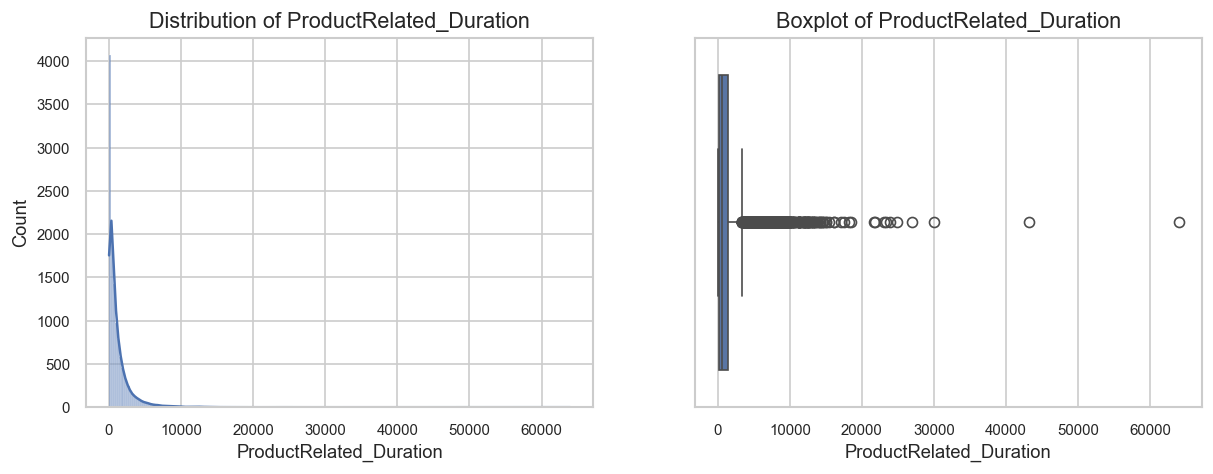

ProductRelated_Duration - Skewness: 7.26, Kurtosis: 137.17
Outliers (IQR method): 961 (7.79%)
Outliers (Z-score method): 219 (1.78%)



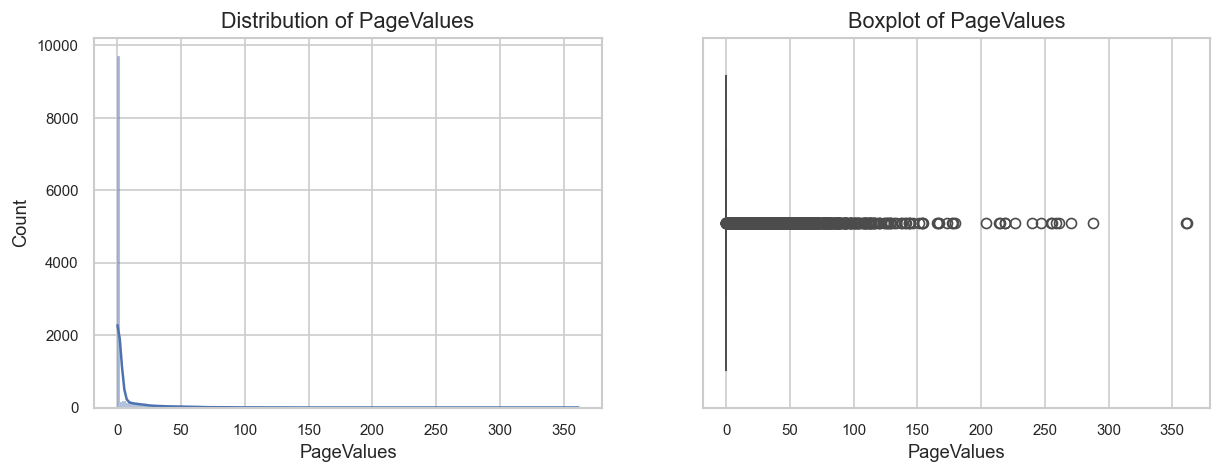

PageValues - Skewness: 6.38, Kurtosis: 65.64
Outliers (IQR method): 2730 (22.14%)
Outliers (Z-score method): 259 (2.10%)

Target Class Imbalance (Revenue):
  False: 10422 (84.53%)
  True: 1908 (15.47%)


In [5]:
continuous_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
categorical_cols = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

for col in ['ProductRelated_Duration', 'PageValues']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Distribution of {col}')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    plt.show()
    
    print(f"{col} - Skewness: {df[col].skew():.2f}, Kurtosis: {df[col].kurt():.2f}")
    lower, upper, n_out, pct_out, _ = eda_utils.detect_outliers_iqr(df, col)
    print(f"Outliers (IQR method): {n_out} ({pct_out:.2f}%)")
    n_z, pct_z, _ = eda_utils.detect_outliers_zscore(df, col)
    print(f"Outliers (Z-score method): {n_z} ({pct_z:.2f}%)\n")

target_counts = df['Revenue'].value_counts()
target_pct = df['Revenue'].value_counts(normalize=True) * 100
print("Target Class Imbalance (Revenue):")
for idx in target_counts.index:
    print(f"  {idx}: {target_counts[idx]} ({target_pct[idx]:.2f}%)")

## Bước 5: Mối quan hệ Đa biến & Tương quan Hệ thống (Multivariate & Dependency Analysis)

**Tư duy của Kỹ sư ML:**
Vì ta đang xây dựng mô hình Tạo sinh (Generative AI), mô hình phải học thuộc lòng mối quan hệ tương quan chéo giữa các cột. Ta không thể chỉ tính ma trận tương quan thông thường (chỉ chạy trên biến số). Ta bắt buộc phải xây dựng **Ma trận liên kết hỗn hợp (Unified Association Matrix)** kết hợp 3 chỉ số:
1. **Pearson Correlation (Số - Số):** Đo lường mối quan hệ tuyến tính chéo.
2. **Cramér's V (Phân loại - Phân loại):** Đo lường độ liên kết phi tuyến giữa hai biến phân loại, dựa trên thống kê Chi-Square (thang đo $[0, 1]$).
3. **Correlation Ratio (Số - Phân loại):** Đo lường mức độ ảnh hưởng của biến phân loại lên biến số (phương sai nội bộ nhóm vs phương sai tổng thể, thang đo $[0, 1]$).

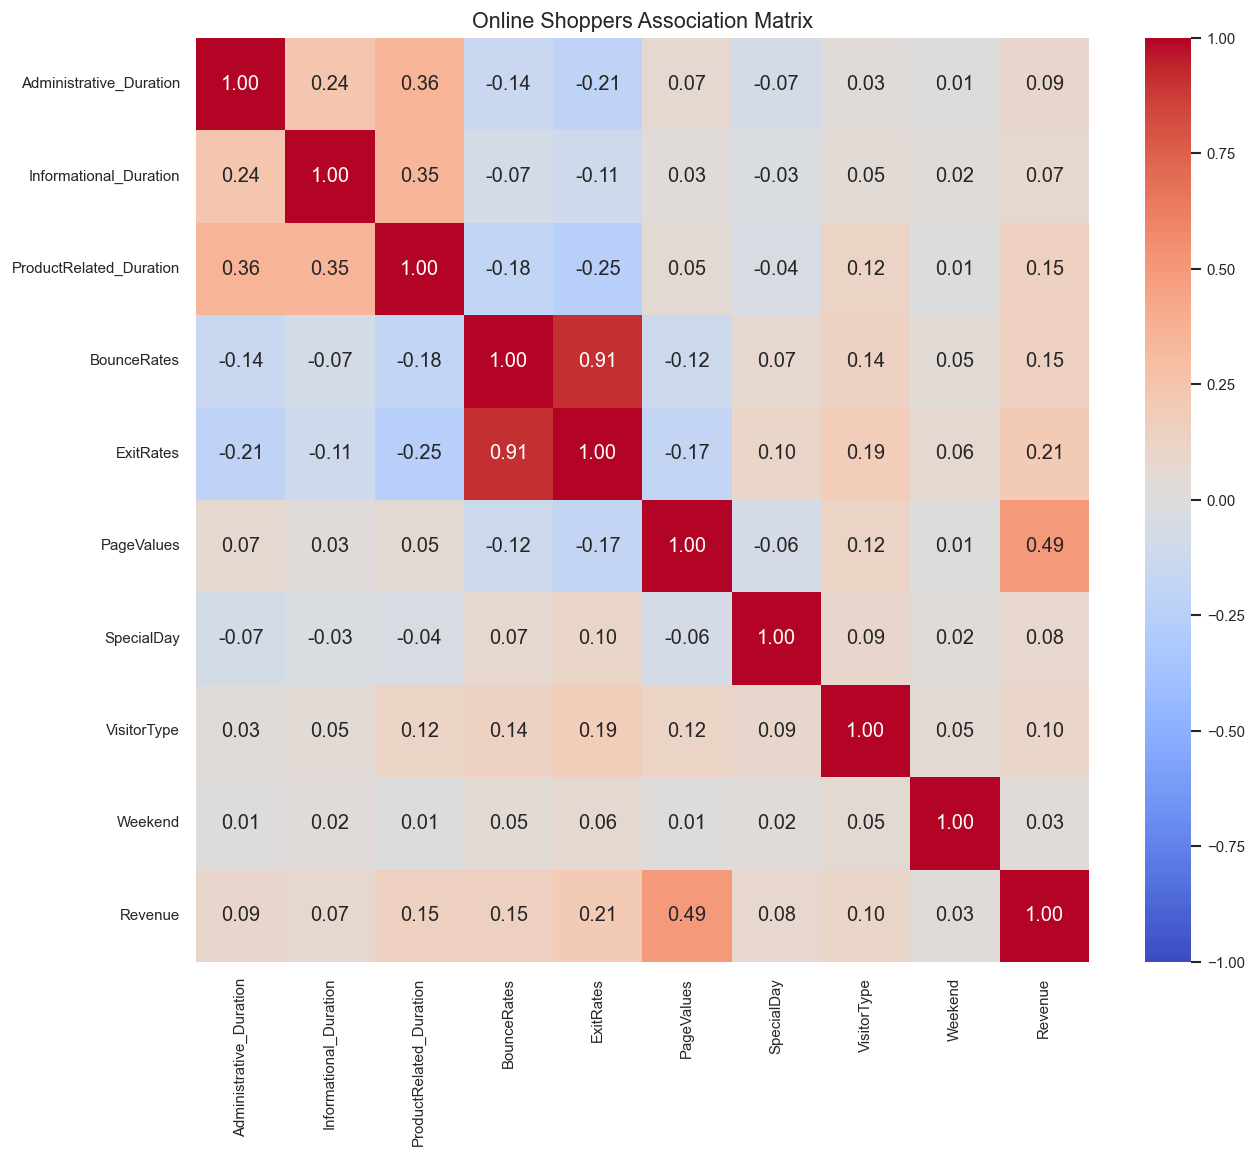

Nhận xét: BounceRates và ExitRates có tương quan tuyến tính mạnh (0.91).


In [6]:
continuous_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
categorical_cols = ['VisitorType', 'Weekend', 'Revenue']

assoc = eda_utils.association_matrix(df, continuous_cols, categorical_cols)
plt.figure(figsize=(12, 10))
sns.heatmap(assoc, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Online Shoppers Association Matrix")
plt.show()

print("Nhận xét: BounceRates và ExitRates có tương quan tuyến tính mạnh (0.91).")

## Bước 6: Trích xuất Quy tắc Cấu hình (Schema Constraints & Pipeline Config)

**Tư duy của Kỹ sư ML:**
Ta đóng gói các luật thống kê khám phá được thành một từ điển cấu hình schema ràng buộc. Đây chính là **"Bản thiết kế" (Transformation Blueprint)** truyền cho Module 1 và Module 2.

In [7]:
schema_constraints = {
    'PII_columns_to_drop': config.ingestion.pii_columns_to_drop,
    'quasi_identifiers': config.ingestion.quasi_identifiers,
    'target_column': config.ingestion.target_column,
    'continuous_features': {col: {'min': float(df[col].min()), 'max': float(df[col].max())} for col in continuous_cols},
    'categorical_features': {col: df[col].unique().tolist() for col in ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', config.ingestion.target_column]}
}
import pprint
pprint.pprint(schema_constraints)

import yaml
schema_path = os.path.abspath(os.path.join('..', 'configs', dataset_name, 'data_schema.yaml'))
with open(schema_path, 'w', encoding='utf-8') as f:
    yaml.safe_dump(schema_constraints, f, default_flow_style=False)
print(f'Saved data schema constraints to {schema_path}')

{'PII_columns_to_drop': [],
 'categorical_features': {'Browser': [1,
                                      2,
                                      3,
                                      4,
                                      5,
                                      6,
                                      7,
                                      10,
                                      8,
                                      9,
                                      12,
                                      13,
                                      11],
                          'Month': ['Feb',
                                    'Mar',
                                    'May',
                                    'Oct',
                                    'June',
                                    'Jul',
                                    'Aug',
                                    'Nov',
                                    'Sep',
                                    'Dec'],
  